# CNN-BiLSTM-Attention Architecture Visualization

Generate a clean architecture block diagram for presentation slides.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np

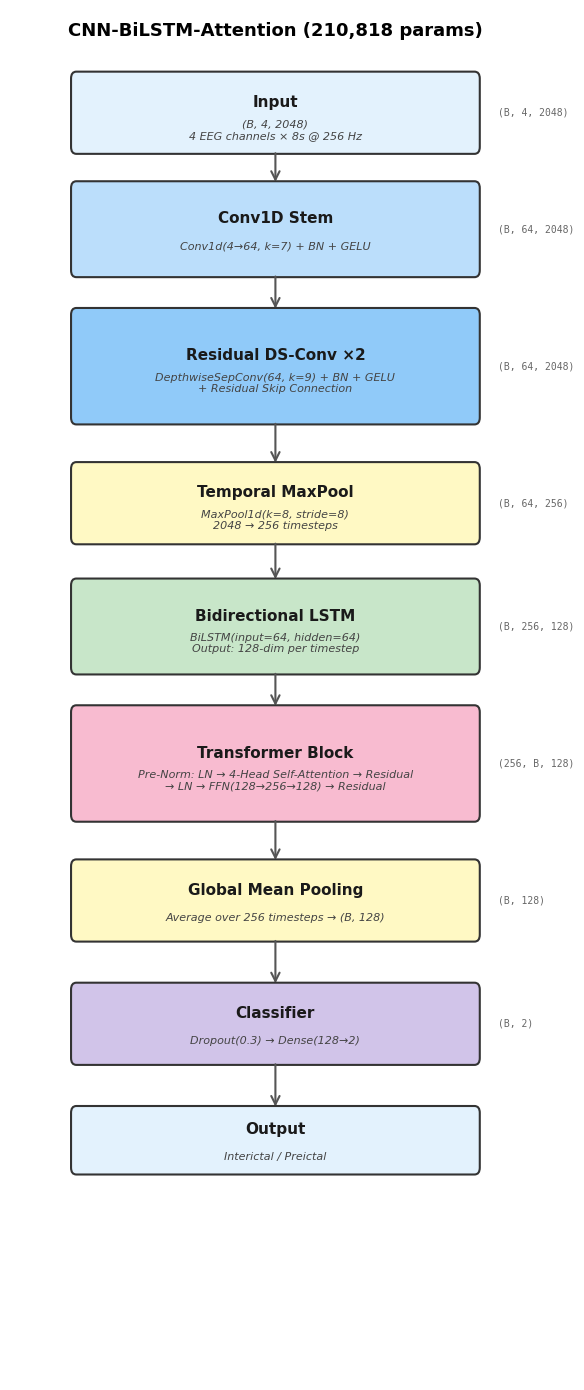

Saved: cnn_bilstm_attn_architecture.png / .pdf


In [2]:
def draw_architecture():
    fig, ax = plt.subplots(1, 1, figsize=(6, 14))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 20)
    ax.axis('off')
    
    # Colors
    c_input = '#E3F2FD'
    c_conv = '#BBDEFB'
    c_res = '#90CAF9'
    c_pool = '#FFF9C4'
    c_lstm = '#C8E6C9'
    c_attn = '#F8BBD0'
    c_clf = '#D1C4E9'
    
    # Block definitions: (y_center, height, color, label, sublabel)
    blocks = [
        (18.5, 1.0, c_input, 'Input', '(B, 4, 2048)\n4 EEG channels × 8s @ 256 Hz'),
        (16.8, 1.2, c_conv, 'Conv1D Stem', 'Conv1d(4→64, k=7) + BN + GELU'),
        (14.8, 1.5, c_res, 'Residual DS-Conv ×2', 'DepthwiseSepConv(64, k=9) + BN + GELU\n+ Residual Skip Connection'),
        (12.8, 1.0, c_pool, 'Temporal MaxPool', 'MaxPool1d(k=8, stride=8)\n2048 → 256 timesteps'),
        (11.0, 1.2, c_lstm, 'Bidirectional LSTM', 'BiLSTM(input=64, hidden=64)\nOutput: 128-dim per timestep'),
        (9.0, 1.5, c_attn, 'Transformer Block', 'Pre-Norm: LN → 4-Head Self-Attention → Residual\n→ LN → FFN(128→256→128) → Residual'),
        (7.0, 1.0, c_pool, 'Global Mean Pooling', 'Average over 256 timesteps → (B, 128)'),
        (5.2, 1.0, c_clf, 'Classifier', 'Dropout(0.3) → Dense(128→2)'),
        (3.5, 0.8, c_input, 'Output', 'Interictal / Preictal'),
    ]
    
    box_width = 7.5
    x_center = 5.0
    
    for i, (y, h, color, label, sublabel) in enumerate(blocks):
        # Draw box
        box = FancyBboxPatch(
            (x_center - box_width/2, y - h/2), box_width, h,
            boxstyle="round,pad=0.1",
            facecolor=color, edgecolor='#333333', linewidth=1.5
        )
        ax.add_patch(box)
        
        # Label
        ax.text(x_center, y + 0.15, label, ha='center', va='center',
                fontsize=11, fontweight='bold', color='#1a1a1a')
        ax.text(x_center, y - 0.25, sublabel, ha='center', va='center',
                fontsize=8, color='#444444', style='italic')
        
        # Arrow to next block
        if i < len(blocks) - 1:
            next_y = blocks[i+1][0]
            next_h = blocks[i+1][1]
            arrow = FancyArrowPatch(
                (x_center, y - h/2 - 0.05),
                (x_center, next_y + next_h/2 + 0.05),
                arrowstyle='->', mutation_scale=15,
                color='#555555', linewidth=1.5
            )
            ax.add_patch(arrow)
    
    # Dimension annotations on the right
    dims = [
        (18.5, '(B, 4, 2048)'),
        (16.8, '(B, 64, 2048)'),
        (14.8, '(B, 64, 2048)'),
        (12.8, '(B, 64, 256)'),
        (11.0, '(B, 256, 128)'),
        (9.0, '(256, B, 128)'),
        (7.0, '(B, 128)'),
        (5.2, '(B, 2)'),
    ]
    
    for y, dim in dims:
        ax.text(9.2, y, dim, ha='left', va='center',
                fontsize=7, color='#666666', family='monospace')
    
    # Title
    ax.text(x_center, 19.7, 'CNN-BiLSTM-Attention (210,818 params)',
            ha='center', va='center', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('cnn_bilstm_attn_architecture.png', dpi=200, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.savefig('cnn_bilstm_attn_architecture.pdf', bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()
    print("Saved: cnn_bilstm_attn_architecture.png / .pdf")

draw_architecture()

## Alternative: Graphviz Flowchart

Produces a cleaner vector diagram — install with `pip install graphviz` and ensure `dot` is on PATH.

In [3]:
try:
    from graphviz import Digraph
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'graphviz', '-q'])
    from graphviz import Digraph

dot = Digraph('CNN_BiLSTM_Attn', format='png')
dot.attr(rankdir='TB', dpi='200', fontname='Helvetica')
dot.attr('node', shape='record', style='filled', fontname='Helvetica', fontsize='10')

# Nodes
dot.node('input', '{Input|4 channels × 2048 samples\\n(8s @ 256 Hz)}', fillcolor='#E3F2FD')
dot.node('stem', '{Conv1D Stem|Conv1d(4→64, k=7, same)\\nBatchNorm + GELU}', fillcolor='#BBDEFB')
dot.node('res', '{ResDSBlock × 2|DepthwiseSep Conv(64, k=9)\\nBN + GELU + Residual Skip}', fillcolor='#90CAF9')
dot.node('pool', '{Temporal MaxPool|kernel=8, stride=8\\n2048 → 256 steps}', fillcolor='#FFF9C4')
dot.node('lstm', '{Bidirectional LSTM|input=64, hidden=64\\noutput=128 (concat)}', fillcolor='#C8E6C9')
dot.node('transformer', '{Transformer Block|4-Head Self-Attention\\nFFN(128→256→128)\\nPre-Norm + Residual}', fillcolor='#F8BBD0')
dot.node('gap', '{Global Mean Pool|avg over 256 timesteps}', fillcolor='#FFF9C4')
dot.node('clf', '{Classifier|Dropout(0.3) → Dense(128→2)}', fillcolor='#D1C4E9')
dot.node('output', '{Output|Interictal / Preictal}', fillcolor='#E3F2FD')

# Edges with dimension labels
dot.edge('input', 'stem', label=' (B,4,2048)')
dot.edge('stem', 'res', label=' (B,64,2048)')
dot.edge('res', 'pool', label=' (B,64,2048)')
dot.edge('pool', 'lstm', label=' (B,64,256)')
dot.edge('lstm', 'transformer', label=' (B,256,128)')
dot.edge('transformer', 'gap', label=' (256,B,128)')
dot.edge('gap', 'clf', label=' (B,128)')
dot.edge('clf', 'output', label=' (B,2)')

dot.render('cnn_bilstm_attn_graphviz', cleanup=True)
print("Saved: cnn_bilstm_attn_graphviz.png")
dot

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

## Model Parameter Summary (from MindSpore)

In [ ]:
import sys
sys.path.insert(0, '../src')

from auras.models.cnn_bilstm_attn import CNNBiLSTMAttn
import mindspore as ms

model = CNNBiLSTMAttn(num_channels=4, num_classes=2)

# Parameter summary table
print(f"{'Layer':<45} {'Shape':<25} {'Params':>10}")
print('─' * 82)
total = 0
for name, param in model.parameters_and_names():
    n = param.size
    total += n
    print(f"{name:<45} {str(param.shape):<25} {n:>10,}")
print('─' * 82)
print(f"{'TOTAL':<45} {'':<25} {total:>10,}")

## Detailed Block Diagram (Horizontal — for wide slides)

In [ ]:
def draw_horizontal_architecture():
    fig, ax = plt.subplots(1, 1, figsize=(16, 4))
    ax.set_xlim(-0.5, 18)
    ax.set_ylim(-1.5, 3)
    ax.axis('off')

    colors = ['#E3F2FD', '#BBDEFB', '#90CAF9', '#FFF9C4', '#C8E6C9', '#F8BBD0', '#FFF9C4', '#D1C4E9', '#E3F2FD']
    labels = ['Input\n4ch×2048', 'Conv Stem\n4→64, k=7', 'ResDSBlock\n×2, k=9', 'MaxPool\n÷8', 
              'BiLSTM\n64→128', 'Transformer\n4-head MHSA', 'Mean Pool\n256→1', 'Dense\n128→2', 'Output\n2 classes']
    dims = ['(4,2048)', '(64,2048)', '(64,2048)', '(64,256)', '(256,128)', '(256,128)', '(128,)', '(2,)', '']

    box_w, box_h = 1.7, 2.0
    gap = 0.3

    for i, (color, label, dim) in enumerate(zip(colors, labels, dims)):
        x = i * (box_w + gap)
        box = FancyBboxPatch((x, 0), box_w, box_h,
                             boxstyle="round,pad=0.1",
                             facecolor=color, edgecolor='#333', linewidth=1.5)
        ax.add_patch(box)
        ax.text(x + box_w/2, box_h/2 + 0.15, label, ha='center', va='center',
                fontsize=9, fontweight='bold')
        if dim:
            ax.text(x + box_w/2, -0.3, dim, ha='center', va='top',
                    fontsize=7, color='#555', family='monospace')
        
        # Arrow
        if i < len(labels) - 1:
            ax.annotate('', xy=(x + box_w + gap - 0.05, box_h/2),
                       xytext=(x + box_w + 0.05, box_h/2),
                       arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

    ax.set_title('CNN-BiLSTM-Attention Architecture (210,818 parameters)', 
                 fontsize=13, fontweight='bold', pad=10)
    
    plt.tight_layout()
    plt.savefig('cnn_bilstm_attn_horizontal.png', dpi=200, bbox_inches='tight',
                facecolor='white')
    plt.show()
    print("Saved: cnn_bilstm_attn_horizontal.png")

draw_horizontal_architecture()

## 3D Block Diagram (Paper-Style)

Uses matplotlib to draw 3D parallelogram blocks where **height ∝ channels** and **width ∝ sequence length**.
This mimics the style from papers like ResNet, VGG, U-Net, etc.

For the absolute best quality, use **PlotNeuralNet** (LaTeX/TikZ): https://github.com/HarisIqbal88/PlotNeuralNet
Or **NN-SVG**: https://alexlenail.me/NN-SVG/

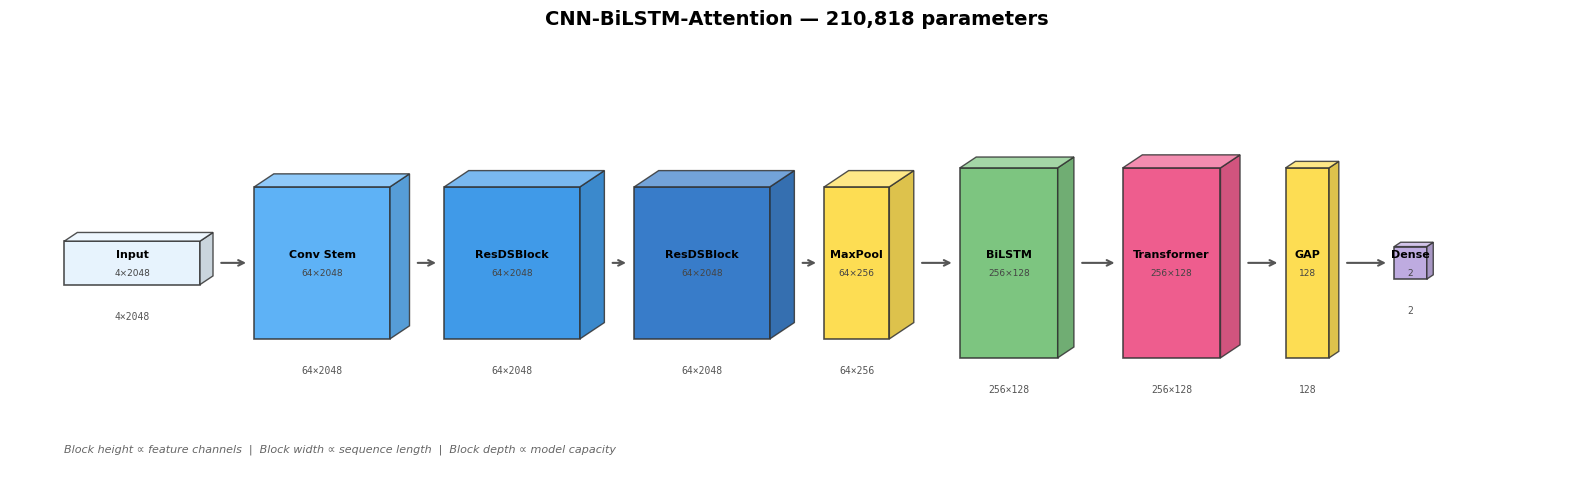

Saved: cnn_bilstm_attn_3d_blocks.png / .pdf


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path
import matplotlib.patheffects as pe
import numpy as np

def draw_3d_block(ax, x, y, width, height, depth, color, label='', sublabel='', alpha=0.85):
    """Draw a 3D parallelogram block (like in CNN architecture papers).
    
    x, y: bottom-left of front face
    width: horizontal extent (represents sequence length)
    height: vertical extent (represents channels/features)
    depth: 3D depth offset (represents a secondary dimension)
    """
    dx, dy = depth * 0.3, depth * 0.2  # 3D offset
    
    # Front face
    front = plt.Polygon(
        [(x, y), (x + width, y), (x + width, y + height), (x, y + height)],
        closed=True, facecolor=color, edgecolor='#333', linewidth=1.2, alpha=alpha, zorder=2
    )
    # Top face
    top = plt.Polygon(
        [(x, y + height), (x + width, y + height), (x + width + dx, y + height + dy), (x + dx, y + height + dy)],
        closed=True, facecolor=_lighten(color, 0.3), edgecolor='#333', linewidth=1.0, alpha=alpha, zorder=3
    )
    # Right face
    right = plt.Polygon(
        [(x + width, y), (x + width + dx, y + dy), (x + width + dx, y + height + dy), (x + width, y + height)],
        closed=True, facecolor=_darken(color, 0.15), edgecolor='#333', linewidth=1.0, alpha=alpha, zorder=2
    )
    
    ax.add_patch(front)
    ax.add_patch(top)
    ax.add_patch(right)
    
    # Label on front face
    if label:
        ax.text(x + width/2, y + height/2 + 0.15, label,
                ha='center', va='center', fontsize=8, fontweight='bold', zorder=5)
    if sublabel:
        ax.text(x + width/2, y + height/2 - 0.2, sublabel,
                ha='center', va='center', fontsize=6.5, color='#444', zorder=5)


def _lighten(color, amount):
    """Lighten a hex color."""
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(color))
    return mcolors.to_hex(c + (1 - c) * amount)

def _darken(color, amount):
    """Darken a hex color."""
    import matplotlib.colors as mcolors
    c = np.array(mcolors.to_rgb(color))
    return mcolors.to_hex(c * (1 - amount))


def draw_paper_style_architecture():
    fig, ax = plt.subplots(1, 1, figsize=(18, 5))
    ax.set_xlim(-1, 28)
    ax.set_ylim(-2, 6)
    ax.axis('off')
    ax.set_aspect('equal')

    # Architecture blocks: (x, width, height, depth, color, label, sublabel)
    # width ~ log(sequence_length), height ~ log(channels), depth ~ secondary dim
    blocks = [
        # x,   w,    h,    d,   color,     label,          sublabel
        (0,    2.5,  0.8,  0.8, '#E3F2FD', 'Input',        '4×2048'),
        (3.5,  2.5,  2.8,  1.2, '#42A5F5', 'Conv Stem',    '64×2048'),
        (7.0,  2.5,  2.8,  1.5, '#1E88E5', 'ResDSBlock',   '64×2048'),
        (10.5, 2.5,  2.8,  1.5, '#1565C0', 'ResDSBlock',   '64×2048'),
        (14.0, 1.2,  2.8,  1.5, '#FDD835', 'MaxPool',      '64×256'),
        (16.5, 1.8,  3.5,  1.0, '#66BB6A', 'BiLSTM',       '256×128'),
        (19.5, 1.8,  3.5,  1.2, '#EC407A', 'Transformer',  '256×128'),
        (22.5, 0.8,  3.5,  0.6, '#FDD835', 'GAP',          '128'),
        (24.5, 0.6,  0.6,  0.4, '#B39DDB', 'Dense',        '2'),
    ]

    for (x, w, h, d, color, label, sublabel) in blocks:
        # Center vertically
        y_offset = (4 - h) / 2
        draw_3d_block(ax, x, y_offset, w, h, d, color, label, sublabel)

    # Draw arrows between blocks
    for i in range(len(blocks) - 1):
        x1 = blocks[i][0] + blocks[i][1] + blocks[i][3] * 0.3 + 0.1
        x2 = blocks[i+1][0] - 0.1
        y_mid = 2.0
        ax.annotate('', xy=(x2, y_mid), xytext=(x1, y_mid),
                   arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

    # Dimension annotations below
    for (x, w, h, d, color, label, sublabel) in blocks:
        y_offset = (4 - h) / 2
        ax.text(x + w/2, y_offset - 0.5, sublabel,
                ha='center', va='top', fontsize=7, family='monospace', color='#555')

    ax.set_title('CNN-BiLSTM-Attention — 210,818 parameters',
                fontsize=14, fontweight='bold', pad=15)

    # Legend for dimensions
    ax.text(0, -1.5, 'Block height ∝ feature channels  |  Block width ∝ sequence length  |  Block depth ∝ model capacity',
            fontsize=8, color='#666', style='italic')

    plt.tight_layout()
    plt.savefig('cnn_bilstm_attn_3d_blocks.png', dpi=250, bbox_inches='tight', facecolor='white')
    plt.savefig('cnn_bilstm_attn_3d_blocks.pdf', bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved: cnn_bilstm_attn_3d_blocks.png / .pdf")

draw_paper_style_architecture()

## PlotNeuralNet (LaTeX/TikZ) — Publication Quality

Uses the [PlotNeuralNet](https://github.com/HarisIqbal88/PlotNeuralNet) library to generate 3D block
diagrams where **height/depth = sequence/spatial size** and **width = number of filters**.

**Setup:** Clone the repo, then run the generated script.
```bash
git clone https://github.com/HarisIqbal88/PlotNeuralNet.git
cd PlotNeuralNet
```

In [5]:
"""
Generate a PlotNeuralNet Python script for CNN-BiLSTM-Attention.

Usage after running this cell:
    cd PlotNeuralNet && bash tikzmake.sh ../cnn_bilstm_attn_plotnn

Or manually:
    cd PlotNeuralNet
    python ../cnn_bilstm_attn_plotnn.py
    pdflatex cnn_bilstm_attn_plotnn.tex
"""

script = r'''
import sys
sys.path.append('PlotNeuralNet')
from pycore.tikzeng import *

# Custom color definitions
def to_custom_colors():
    return r"""
\def\ConvColor{rgb:blue,5;white,3}
\def\ConvReluColor{rgb:blue,5;red,3;white,2}
\def\PoolColor{rgb:red,1;black,0.3}
\def\UnpoolColor{rgb:blue,2;green,1;black,0.3}
\def\FcColor{rgb:magenta,5;black,3}
\def\FcReluColor{rgb:blue,5;red,5;white,4}
\def\SoftmaxColor{rgb:magenta,5;black,7}
\def\SumColor{rgb:blue,5;green,15}
\def\LstmColor{rgb:green,5;black,2}
\def\AttnColor{rgb:red,4;magenta,3;white,2}
"""

# Custom layer: colored box with custom fill
def to_custom_box(name, fill_color, s_filer="", n_filer="", offset="(0,0,0)",
                  to="(0,0,0)", width=1, height=40, depth=40, caption=" "):
    return r"""
\pic[shift={""" + offset + """}] at """ + to + r"""
    {Box={
        name=""" + name + """,
        caption=""" + caption + r""",
        xlabel={{""" + str(n_filer) + """, }},
        zlabel=""" + str(s_filer) + """,
        fill=""" + fill_color + """,
        height=""" + str(height) + """,
        width=""" + str(width) + """,
        depth=""" + str(depth) + """
        }
    };
"""

# --- Architecture definition ---
# height/depth = proportional to spatial/temporal size
# width = proportional to number of channels/filters (log-scaled)
#
# Our model: Input(4,2048) -> Conv(64,2048) -> ResDSx2(64,2048) -> Pool(64,256)
#            -> BiLSTM(256,128) -> Transformer(256,128) -> GAP(128) -> Dense(2)

arch = [
    to_head('PlotNeuralNet'),
    to_cor(),
    # Override colors
    to_custom_colors(),
    to_begin(),

    # Input: 4 channels, 2048 timesteps
    # height=40 (represents 2048), depth=40, width=1 (4 channels - thin)
    to_Conv(
        name="input",
        s_filer=2048,
        n_filer=4,
        offset="(0,0,0)",
        to="(0,0,0)",
        width=0.5,
        height=40,
        depth=40,
        caption="Input"
    ),

    # Conv1D Stem: 64 filters, 2048 timesteps
    # width=3 (64 channels), height/depth=40 (2048 seq len)
    to_Conv(
        name="stem",
        s_filer=2048,
        n_filer=64,
        offset="(2,0,0)",
        to="(input-east)",
        width=3,
        height=40,
        depth=40,
        caption="Conv Stem"
    ),
    to_connection("input", "stem"),

    # ResDSBlock 1: 64 filters, 2048 timesteps
    to_Conv(
        name="res1",
        s_filer=2048,
        n_filer=64,
        offset="(1.5,0,0)",
        to="(stem-east)",
        width=3,
        height=40,
        depth=40,
        caption="ResDS$_1$"
    ),
    to_connection("stem", "res1"),

    # ResDSBlock 2: 64 filters, 2048 timesteps
    to_Conv(
        name="res2",
        s_filer=2048,
        n_filer=64,
        offset="(1.5,0,0)",
        to="(res1-east)",
        width=3,
        height=40,
        depth=40,
        caption="ResDS$_2$"
    ),
    to_connection("res1", "res2"),

    # MaxPool: 64 filters, 256 timesteps (8x reduction)
    # height/depth shrink to 256/2048 * 40 = 5
    to_Pool(
        name="pool",
        offset="(1.5,0,0)",
        to="(res2-east)",
        width=1,
        height=20,
        depth=20,
        opacity=0.5,
        caption="MaxPool"
    ),
    to_connection("res2", "pool"),

    # BiLSTM: output 128-dim, 256 timesteps
    # height/depth=20 (256 steps), width=5 (128 features)
    to_custom_box(
        name="lstm",
        fill_color=r"\LstmColor",
        s_filer=256,
        n_filer=128,
        offset="(2,0,0)",
        to="(pool-east)",
        width=5,
        height=20,
        depth=20,
        caption="BiLSTM"
    ),
    to_connection("pool", "lstm"),

    # Transformer Block: 128-dim, 256 timesteps
    # Same spatial dims as LSTM, different color
    to_custom_box(
        name="attn",
        fill_color=r"\AttnColor",
        s_filer=256,
        n_filer=128,
        offset="(2,0,0)",
        to="(lstm-east)",
        width=5,
        height=20,
        depth=20,
        caption="MHSA"
    ),
    to_connection("lstm", "attn"),

    # Global Average Pooling: 128-dim, 1 timestep
    to_Pool(
        name="gap",
        offset="(1.5,0,0)",
        to="(attn-east)",
        width=3,
        height=3,
        depth=3,
        opacity=0.6,
        caption="GAP"
    ),
    to_connection("attn", "gap"),

    # Dense classifier: 2 outputs
    to_SoftMax(
        name="dense",
        s_filer=2,
        offset="(1.5,0,0)",
        to="(gap-east)",
        width=1.5,
        height=3,
        depth=25,
        caption="FC"
    ),
    to_connection("gap", "dense"),

    to_end()
]


def main():
    namefile = 'cnn_bilstm_attn_plotnn'
    to_generate(arch, namefile + '.tex')
    print(f"Generated: {namefile}.tex")
    print(f"Compile with:")
    print(f"  cd PlotNeuralNet && pdflatex ../{namefile}.tex")
    print(f"  OR: cd PlotNeuralNet && bash ../tikzmake.sh ../{namefile}")

if __name__ == '__main__':
    main()
'''

# Write the script
output_path = 'cnn_bilstm_attn_plotnn.py'
with open(output_path, 'w') as f:
    f.write(script)

print(f"Written: {output_path}")
print()
print("To generate the diagram:")
print("  1. git clone https://github.com/HarisIqbal88/PlotNeuralNet.git")
print("  2. python cnn_bilstm_attn_plotnn.py")
print("  3. cd PlotNeuralNet && pdflatex ../cnn_bilstm_attn_plotnn.tex")
print()
print("The key dimensions:")
print("  - height/depth of block = spatial/temporal dimension (sequence length)")
print("  - width (thickness) of block = number of channels/features")
print("  Blocks shrink after pooling, get thicker with more features.")

Written: cnn_bilstm_attn_plotnn.py

To generate the diagram:
  1. git clone https://github.com/HarisIqbal88/PlotNeuralNet.git
  2. python cnn_bilstm_attn_plotnn.py
  3. cd PlotNeuralNet && pdflatex ../cnn_bilstm_attn_plotnn.tex

The key dimensions:
  - height/depth of block = spatial/temporal dimension (sequence length)
  - width (thickness) of block = number of channels/features
  Blocks shrink after pooling, get thicker with more features.
